In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_folder = '../data/'
tous_les_fichiers = [f for f in os.listdir(data_folder) if f.endswith('.csv') and f != 'processed_dataset.csv']
print(f'Nombre de fichiers : {len(tous_les_fichiers)}')

liste_df = []
for fichier in tous_les_fichiers:
    chemin = os.path.join(data_folder, fichier)
    df_temp = pd.read_csv(chemin)
    df_temp['ride_id'] = fichier.replace('.csv', '')
    liste_df.append(df_temp)

df = pd.concat(liste_df, ignore_index=True)
print(f'Total de lignes : {len(df)}')
df.head()

Nombre de fichiers : 163


Total de lignes : 1620455


,secs,km,power,hr,cad,alt,ride_id
0,0,0.00000,0,84,0,1309.8,155
1,1,0.00020,0,84,0,1309.8,155
2,4,0.00020,0,84,0,1310.0,155
3,5,0.00252,0,84,0,1296.8,155
4,6,0.00791,0,85,0,1296.8,155


In [2]:
print('Shape du dataset :', df.shape)
print(df.dtypes)
print(df.isnull().sum())

Shape du dataset : (1620455, 7)
secs         int64
km         float64
power        int64
hr           int64
cad          int64
alt        float64
ride_id     object
dtype: object
secs       0
km         0
power      0
hr         0
cad        0
alt        0
ride_id    0
dtype: int64


In [3]:
df.describe().round(2)

,secs,km,power,hr,cad,alt
count,1620455.00,1620455.00,1620455.00,1620455.00,1620455.00,1620455.00
mean,6974.18,48.50,191.73,144.91,74.76,626.46
std,5399.84,34.74,110.57,27.61,28.84,581.20
min,0.00,0.00,0.00,0.00,0.00,-86.40
25%,2768.00,20.41,137.00,128.00,71.00,86.20
50%,5755.00,42.47,205.00,147.00,85.00,410.40
75%,9792.00,70.97,260.00,165.00,91.00,1159.60
max,30221.00,179.89,1250.00,205.00,254.00,2378.20


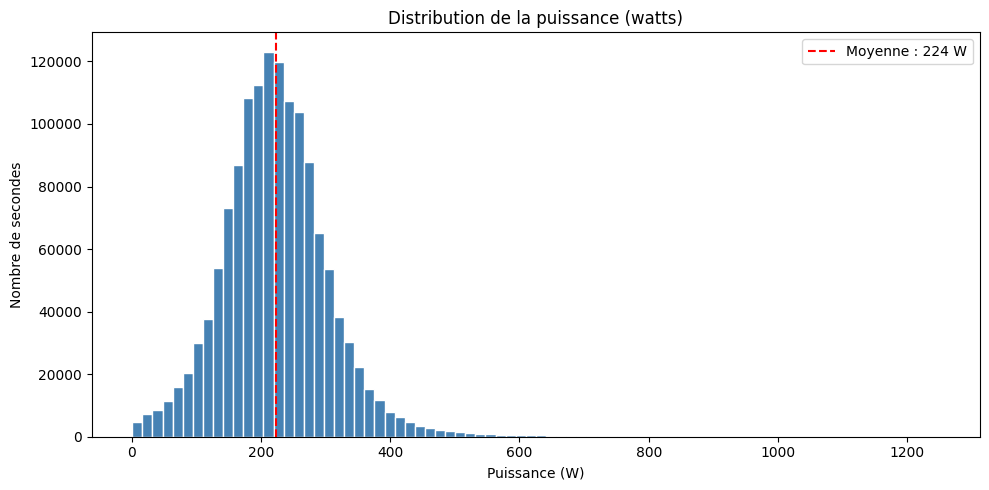

Puissance moyenne : 223.6 W
Puissance max : 1250 W


In [4]:
puissance_active = df[df['power'] > 0]['power']

plt.figure(figsize=(10, 5))
plt.hist(puissance_active, bins=80, color='steelblue', edgecolor='white')
plt.title('Distribution de la puissance (watts)')
plt.xlabel('Puissance (W)')
plt.ylabel('Nombre de secondes')
plt.axvline(puissance_active.mean(), color='red', linestyle='--', label=f'Moyenne : {puissance_active.mean():.0f} W')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/distribution_puissance.png')
plt.show()
print(f'Puissance moyenne : {puissance_active.mean():.1f} W')
print(f'Puissance max : {puissance_active.max():.0f} W')

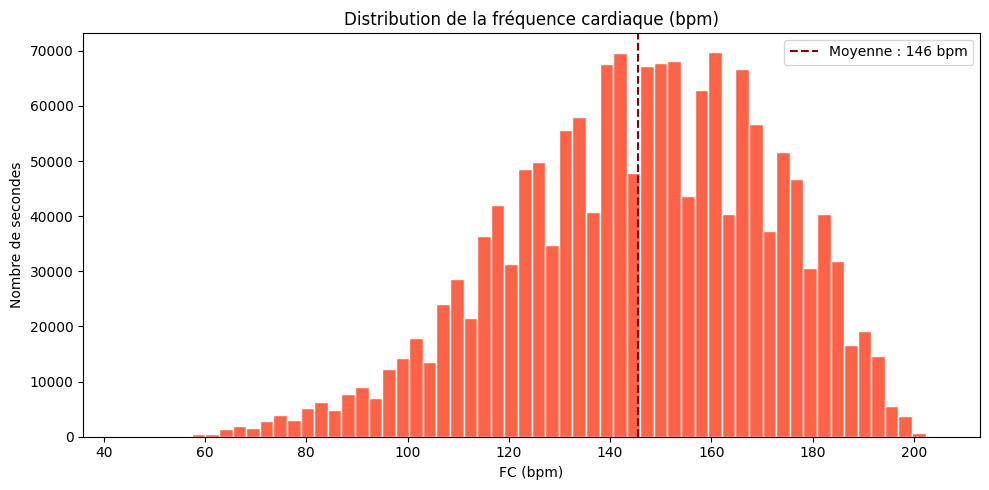

In [5]:
hr_active = df[df['hr'] > 0]['hr']

plt.figure(figsize=(10, 5))
plt.hist(hr_active, bins=60, color='tomato', edgecolor='white')
plt.title('Distribution de la fréquence cardiaque (bpm)')
plt.xlabel('FC (bpm)')
plt.ylabel('Nombre de secondes')
plt.axvline(hr_active.mean(), color='darkred', linestyle='--', label=f'Moyenne : {hr_active.mean():.0f} bpm')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/distribution_fc.png')
plt.show()

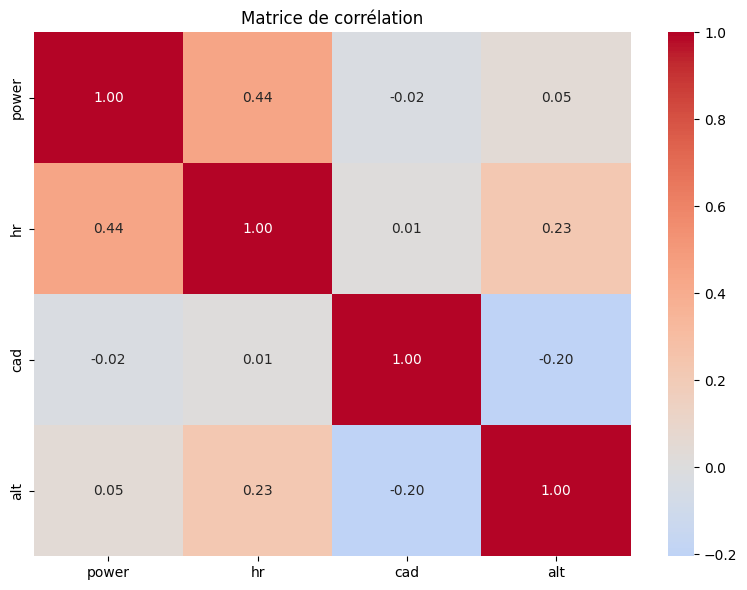

In [6]:
df_actif = df[df['power'] > 0].copy()

colonnes_numeriques = ['power', 'hr', 'cad', 'alt']
matrice_corr = df_actif[colonnes_numeriques].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrice_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.savefig('../plots/correlation_matrix.png')
plt.show()

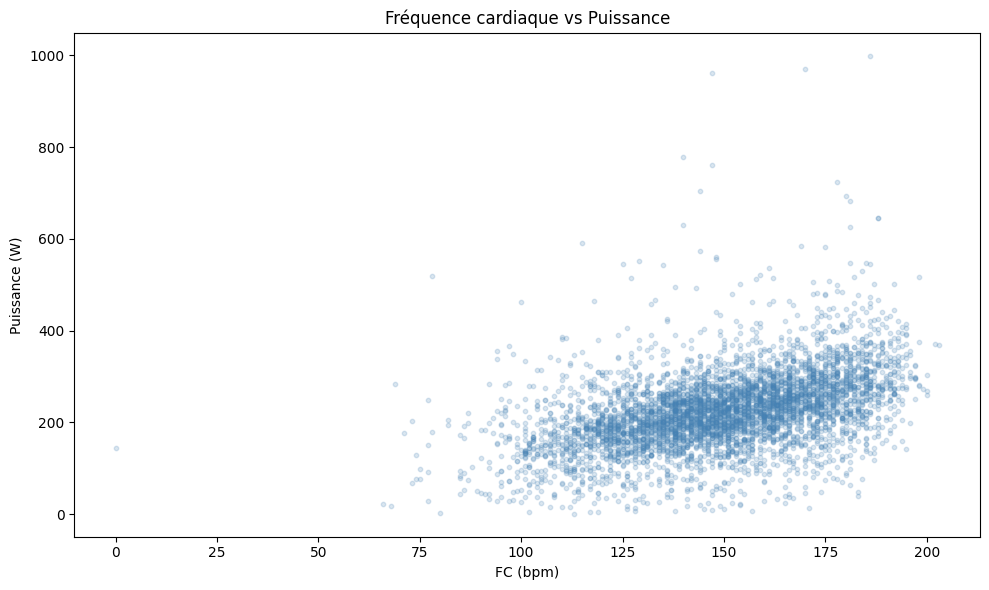

In [7]:
echantillon = df_actif.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(echantillon['hr'], echantillon['power'], alpha=0.2, color='steelblue', s=10)
plt.title('Fréquence cardiaque vs Puissance')
plt.xlabel('FC (bpm)')
plt.ylabel('Puissance (W)')
plt.tight_layout()
plt.savefig('../plots/hr_vs_power.png')
plt.show()

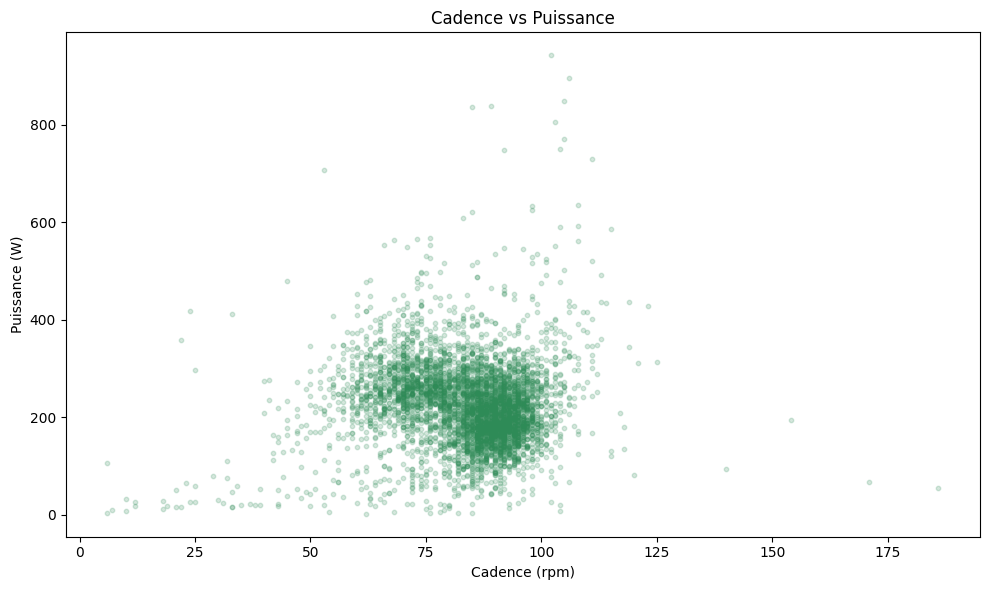

In [8]:
cad_actif = df_actif[df_actif['cad'] > 0].sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(cad_actif['cad'], cad_actif['power'], alpha=0.2, color='seagreen', s=10)
plt.title('Cadence vs Puissance')
plt.xlabel('Cadence (rpm)')
plt.ylabel('Puissance (W)')
plt.tight_layout()
plt.savefig('../plots/cadence_vs_power.png')
plt.show()

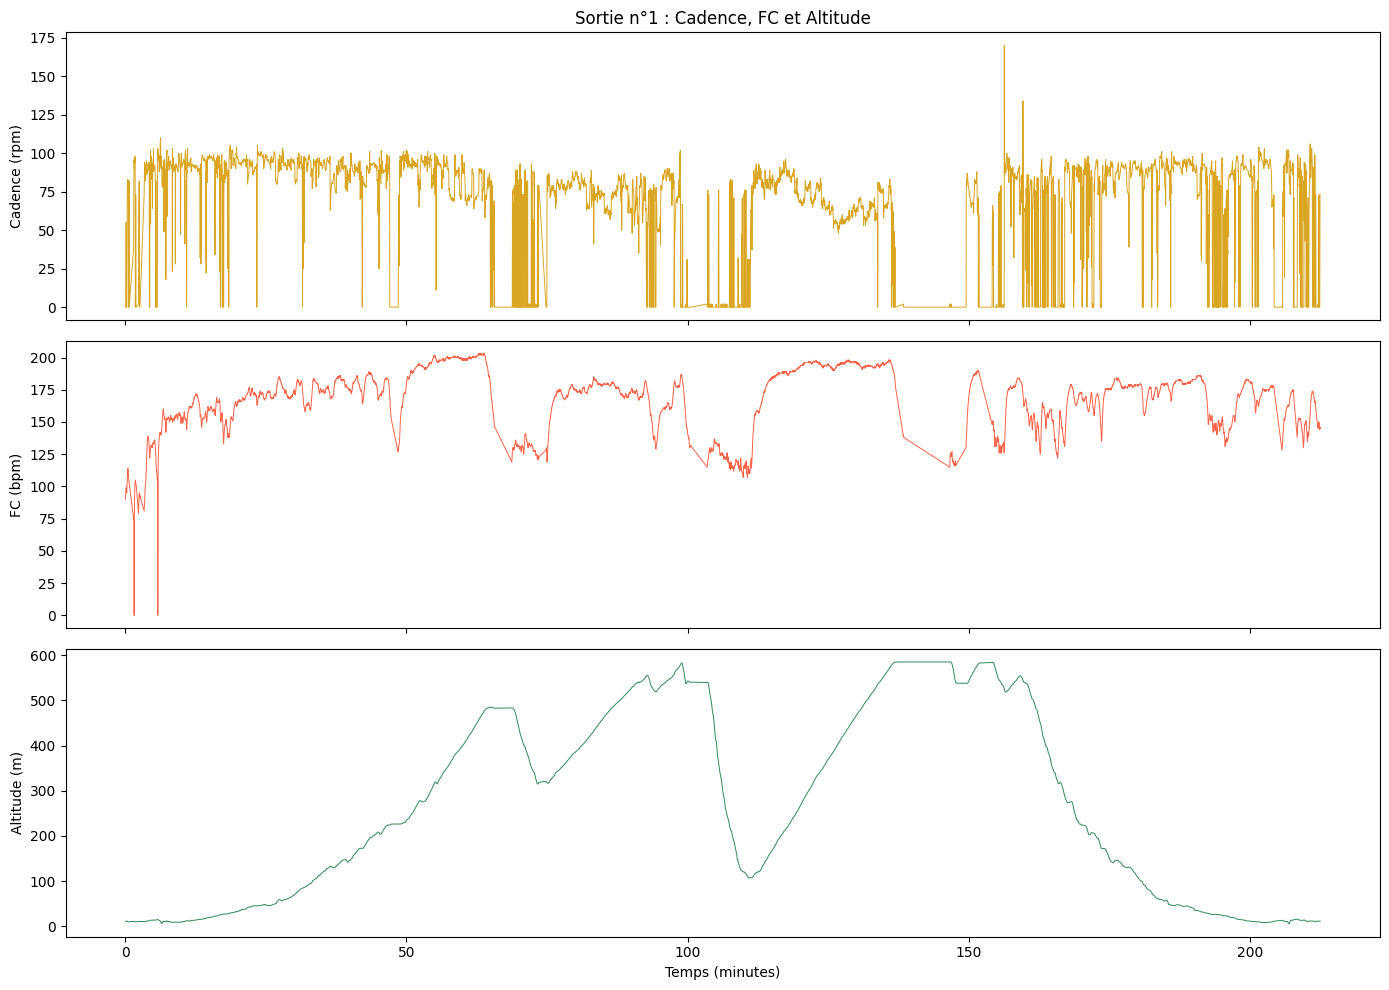

In [9]:
sortie_exemple = df[df['ride_id'] == '1'].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sortie_exemple['secs'] / 60, sortie_exemple['cad'], color='goldenrod', linewidth=0.7)
axes[0].set_ylabel('Cadence (rpm)')
axes[0].set_title('Sortie n°1 : Cadence, FC et Altitude')

axes[1].plot(sortie_exemple['secs'] / 60, sortie_exemple['hr'], color='tomato', linewidth=0.7)
axes[1].set_ylabel('FC (bpm)')

axes[2].plot(sortie_exemple['secs'] / 60, sortie_exemple['alt'], color='seagreen', linewidth=0.7)
axes[2].set_ylabel('Altitude (m)')
axes[2].set_xlabel('Temps (minutes)')

plt.tight_layout()
plt.savefig('../plots/exemple_sortie.png')
plt.show()

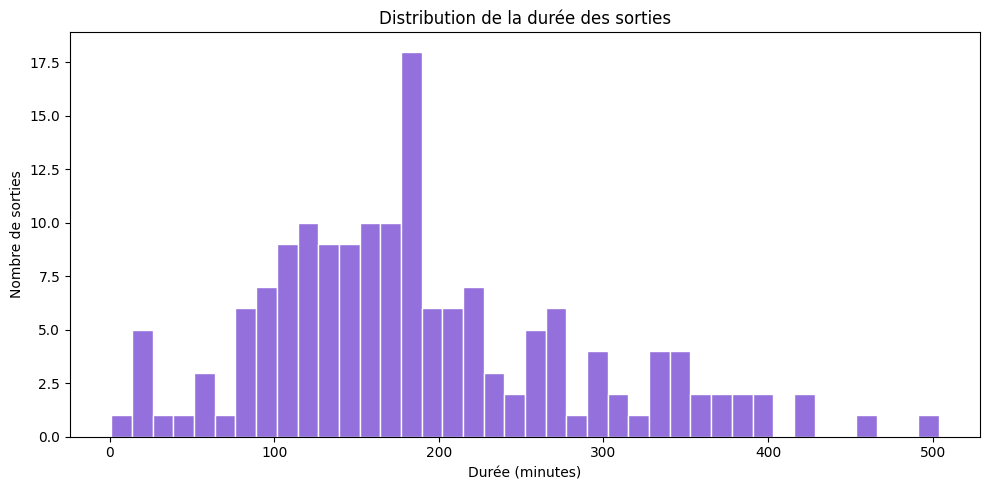

Durée moyenne : 190 minutes
Min : 1 min, Max : 504 min


In [10]:
durees = df.groupby('ride_id')['secs'].max() / 60

plt.figure(figsize=(10, 5))
plt.hist(durees, bins=40, color='mediumpurple', edgecolor='white')
plt.title('Distribution de la durée des sorties')
plt.xlabel('Durée (minutes)')
plt.ylabel('Nombre de sorties')
plt.tight_layout()
plt.savefig('../plots/distribution_durees.png')
plt.show()
print(f'Durée moyenne : {durees.mean():.0f} minutes')
print(f'Min : {durees.min():.0f} min, Max : {durees.max():.0f} min')